# Trabalho Gomes & Canoso Bank

O Objectivo deste Projecto é criar um modelo preditivo de risco de crédito, ou seja, ajudarmos o cliente (sector bancário) a prever a probabilidade de incumprimento do pagamento de cartões de crédito. \
Ao longo deste Projecto serão analisados os dados reais, identificados os principais factores associados ao incumprimento e preparado o modelo preditivo, premitindo ajudar o cliente a ajustar o treshold de decisão de forma a minimizar os prejuízos.

Os passos a serem aplicados serão os seguintes: \
Parte I - Análise Exploratória: importação e preparação dos dados \
Parte II - Pré-processamento: preparar e modelar os dados para o modelo de previsão \
Parte III - Criação e modelagem do modelo de previsão \
Parte IV - Ajuste de treshold; ajustar o modelo para minimizar ao máximo os prejuízos

### PARTE I - ANÁLISE EXPLORATÓRIA

In [138]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from scipy.stats import shapiro, skew, kurtosis
import statsmodels.api as sm

In [139]:
# Importação da Base de Dados
df = pd.read_csv (r"C:\Users\ctorrinha\OneDrive - iBASIS\Documents\Cátia\Formações\GOMES&CANOSO\MACHINE LEARNING\Trabalho Final\Tenya_Dataset.csv", sep = ';')
df.head()

,ID_Cliente,Limite_Credito,Genero,Escolaridade,Estado_Civil,Idade,Atraso_Pagamento_Setembro,Atraso_Pagamento_Agosto,Atraso_Pagamento_Julho,Atraso_Pagamento_Junho,...,Fatura_Junho,Fatura_Maio,Fatura_Abril,Pagamento_Setembro,Pagamento_Agosto,Pagamento_Julho,Pagamento_Junho,Pagamento_Maio,Pagamento_Abril,Incumprimento_Mes_Seguinte
0,1,20000,Feminino,2,1,24.0,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,Feminino,2,2,26.0,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,Feminino,2,2,34.0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,Feminino,2,1,37.0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,Masculino,2,1,57.0,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


1 = probabilidade de incumprir \
0 = não probabilidade de incumprimento

In [141]:
# Informação do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID_Cliente                  30000 non-null  int64  
 1   Limite_Credito              30000 non-null  int64  
 2   Genero                      29997 non-null  object 
 3   Escolaridade                30000 non-null  int64  
 4   Estado_Civil                30000 non-null  int64  
 5   Idade                       29995 non-null  float64
 6   Atraso_Pagamento_Setembro   30000 non-null  int64  
 7   Atraso_Pagamento_Agosto     30000 non-null  int64  
 8   Atraso_Pagamento_Julho      30000 non-null  int64  
 9   Atraso_Pagamento_Junho      30000 non-null  int64  
 10  Atraso_Pagamento_Maio       30000 non-null  int64  
 11  Atraso_Pagamento_Abril      30000 non-null  int64  
 12  Fatura_Setembro             30000 non-null  int64  
 13  Fatura_Agosto               300

Após uma primeira análise, foi observado o seguinte:\
-A base de dados contém 25 colunas;\
-Cada coluna contém 30000 registos (linhas);\
-Existem duas colunas com valores em falta: Idade e Género;\
Estas duas colunas são variáveis categóricas, ou seja, expressam qualidades, descrevem características.

In [142]:
# Confirmar o nº de colunas e linhas
df.shape

(30000, 25)

In [143]:
# Verificar quais os tipos de dados existentes na base de dados
df.dtypes

ID_Cliente                      int64
Limite_Credito                  int64
Genero                         object
Escolaridade                    int64
Estado_Civil                    int64
Idade                         float64
Atraso_Pagamento_Setembro       int64
Atraso_Pagamento_Agosto         int64
Atraso_Pagamento_Julho          int64
Atraso_Pagamento_Junho          int64
Atraso_Pagamento_Maio           int64
Atraso_Pagamento_Abril          int64
Fatura_Setembro                 int64
Fatura_Agosto                   int64
Fatura_Julho                    int64
Fatura_Junho                    int64
Fatura_Maio                     int64
Fatura_Abril                    int64
Pagamento_Setembro              int64
Pagamento_Agosto                int64
Pagamento_Julho                 int64
Pagamento_Junho                 int64
Pagamento_Maio                  int64
Pagamento_Abril                 int64
Incumprimento_Mes_Seguinte      int64
dtype: object

Ao criar uma segunda análise, confirmamos que as variáveis Idade e Género são categóricas, e terão de ser tratadas e transformadas em variáveis quantitativas, pois o modelo de Machine Learning não aceita valores categóricos, apenas numéricos.

In [144]:
# Cálculo da taxa de incumprimento
target_col = 'Incumprimento_Mes_Seguinte'

taxa_incumprimento = df[target_col].mean()*100

print (f"A taxa de incumprimento é: {taxa_incumprimento: .2f}% ")

A taxa de incumprimento é:  22.12% 


### Análise Exploratória

#### Estatísticas Descritivas para Colunas Numéricas (Gráficos e Visuais)

In [145]:
# Criar uma tabela de estatística descritiva (média, mediana, desvio padrão, valor minimo e máximo)

display(df.describe())

,ID_Cliente,Limite_Credito,Escolaridade,Estado_Civil,Idade,Atraso_Pagamento_Setembro,Atraso_Pagamento_Agosto,Atraso_Pagamento_Julho,Atraso_Pagamento_Junho,Atraso_Pagamento_Maio,...,Fatura_Junho,Fatura_Maio,Fatura_Abril,Pagamento_Setembro,Pagamento_Agosto,Pagamento_Julho,Pagamento_Junho,Pagamento_Maio,Pagamento_Abril,Incumprimento_Mes_Seguinte
count,30000.000000,30000.000000,30000.000000,30000.000000,29995.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.853133,1.551867,35.485581,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.790349,0.521970,9.218670,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Foi criada uma tabela de estatística descritiva e foi verificado o seguinte:\
Variável Limite de Crédito:\
-A média é mais elevada em relação à mediana, o que indica uma assimetria positiva nos dados; pode indicar a existência de outliers, dados atípicos, fora do pafrão geral da base de dados. A média é sensível a estes valores, portanto podem existir outliers com valores elevados ou que a fazem deslocar-se para cima;\
-O desvio padrão é elevado o que pode indicar que os valores estão muito dispersos;\
-Intervalos Inter-quartis (25% e 75%): A maioria dos clientes têm valores de crédito entre 50.0000 e 240.000; este valor é muito amplo, e mostra que os limites de crédito são muito diferentes. No entanto esta variabilidade é benéfica para o modelo de Machine Learning, pois ajuda a distinguir padrões de risco.

#### O próximo passo será verificar a assimetria das variáveis numéricas, se é positiva ou negativa.

In [146]:
# Usando as medidas estatísticas, Skewness e Kurtosis, vamos verificar a assimetria dos dados.

numerical_cols = df.select_dtypes(include=np.number).columns

skewness = df[numerical_cols].skew()
kurtosis = df[numerical_cols].kurt()

stats_df = pd.DataFrame({
    'Skewness': skewness,
    'Kurtosis': kurtosis
})

display(stats_df)

,Skewness,Kurtosis
ID_Cliente,0.000000,-1.200000
Limite_Credito,0.992867,0.536263
Escolaridade,0.970972,2.078622
Estado_Civil,-0.018742,-1.363368
Idade,0.732159,0.043773
Atraso_Pagamento_Setembro,0.731975,2.720715
Atraso_Pagamento_Agosto,0.790565,1.570418
Atraso_Pagamento_Julho,0.840682,2.084436
Atraso_Pagamento_Junho,0.999629,3.496983
Atraso_Pagamento_Maio,1.008197,3.989748


Análise às medidas estatísticas:\
-Skweness(Assimetria): revela que a maioria das variáveis apresenta assimetria positiva. Isto demonstra a presença de um pequeno grupo de clientes com valores muito elevados, que distorcem a distribuição e aumentam a média, como foi verificado na tabela cima;\
-Kurtosis (Curtose): Confirma o padrão revelado na assimetria e indica a presença de outliers.

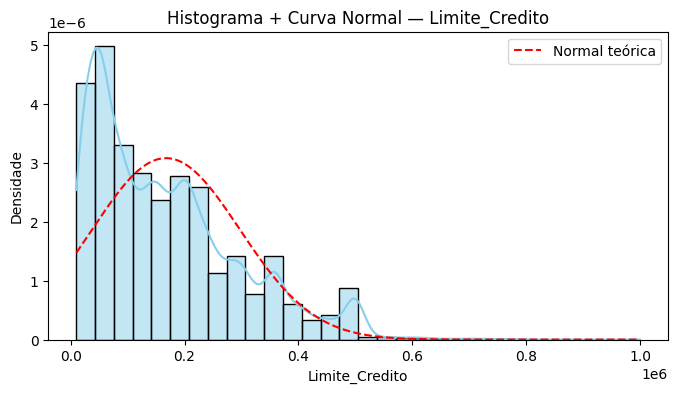

In [147]:
# Criar um Histograma para confirmar a assimetria positiva - Variável Limite_Credito

from scipy.stats import norm

col = 'Limite_Credito'
data = df [col].dropna() # eliminar valores em branco

plt.figure (figsize = (8,4))
sns.histplot (data, bins=30, kde=True, color='skyblue', stat='density')

mean = data.mean()
std = data.std()
xmin, xmax = data.min(), data.max()
x = np.linspace (xmin, xmax, 200)
y = norm.pdf(x,mean,std)

plt.plot(x, y, "r--", label="Normal teórica")
plt.title(f"Histograma + Curva Normal — {col}")
plt.xlabel(col)
plt.ylabel("Densidade")
plt.legend()
plt.show()

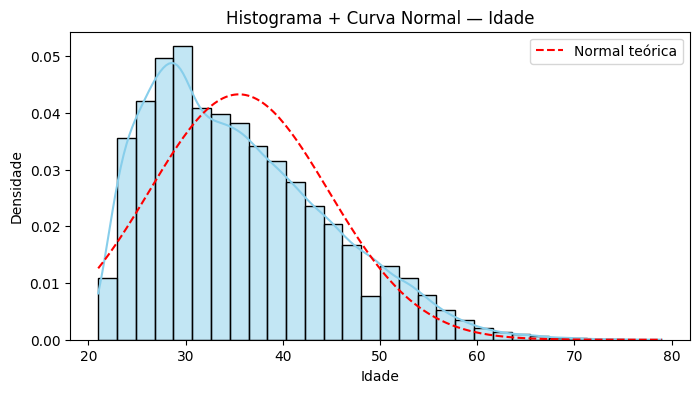

In [158]:
# Criar um Histograma para confirmar a assimetria positiva - Variável Idade

col2 = 'Idade'
data2 = df [col2].dropna()

plt.figure (figsize = (8,4))
sns.histplot (data2, bins=30, kde=True, color='skyblue', stat='density')

mean2 = data2.mean()
std2 = data2.std()
xmin2, xmax2 = data2.min(), data2.max()
x2 = np.linspace (xmin2, xmax2, 200)
y2 = norm.pdf(x2,mean2,std2)

plt.plot(x2, y2, "r--", label="Normal teórica")
plt.title(f"Histograma + Curva Normal — {col2}")
plt.xlabel(col2)
plt.ylabel("Densidade")
plt.legend()
plt.show()

Ao analisar a variável Idade, confirmamos que também existe assimetria positiva, com cauda inclinação à direita e cauda algo longa.\
Ou seja, existem outliers e esta variável também não segue uma distribuição normal.

C:\Users\ctorrinha\AppData\Local\anaconda3\envs\myenv\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


<Figure size 800x400 with 0 Axes>

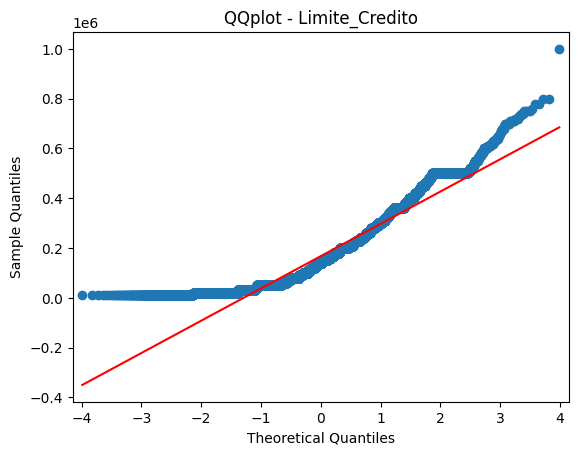

In [149]:
# QQplot à Variável Limite_Credito para confirmar a sua distribuição

plt.figure (figsize = (8,4))
sm.qqplot (data = data, line = 's', marker = 'o', color = 'blue')
plt.title (f"QQplot - {col}")


plt.show()

<Figure size 800x400 with 0 Axes>

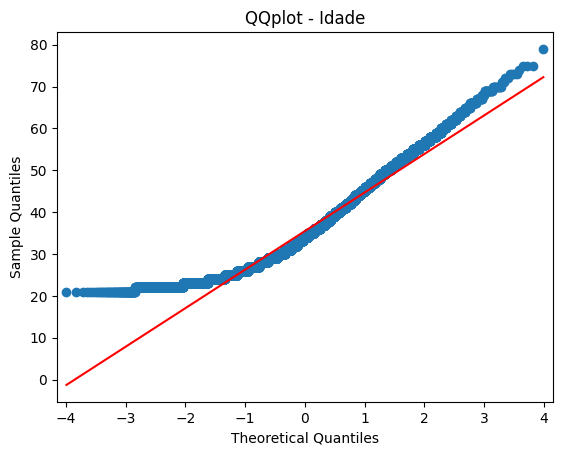

In [150]:
# QQplot à Variável Idade para confirmar a sua distribuição

plt.figure (figsize = (8,4))
sm.qqplot (data2, line = 's', marker = 'o', color = 'blue')
plt.title (f"QQplot - {col2}")


plt.show()

## Teste de Hipóteses

**Hipotése nula (H0)** = A variável Limite Crédito e Idade seguem uma distribuição normal

**Hipótese alternativa (H1)** = A variável Limite Crédito e Idade não seguem uma distribuição normal

Quando o p-value > 0.05 aceitamos H0.

Se o p-value for <= 0.05 rejeitamos H0, logo não é normal

In [151]:
# Teste de Normalidade - Limite_Credito
# stat, p = shapiro(data)

from scipy.stats import kstest, norm

# 'data' já contém a série 'Limite_Credito'
# Precisamos especificar a distribuição contra a qual queremos testar (normal)
# e os parâmetros da normal (média e desvio padrão de 'data').

mean_data = data.mean()
std_data = data.std()

stat, p_value = kstest(data, 'norm', args=(mean_data, std_data))

print(f"Estatística do teste de Kolmogorov-Smirnov: {stat:.4f}")
print(f"Valor-p: {p_value:.4f}")

alpha = 0.05 # Nível de significância

if p_value < alpha:
    print("Rejeitamos a hipótese nula (H0): A variável Limite_Credito NÃO segue uma distribuição normal.")
else:
    print("Não há evidências suficientes para rejeitar a hipótese nula (H0): A variável Limite_Credito SEGUE uma distribuição normal.")

Estatística do teste de Kolmogorov-Smirnov: 0.1151
Valor-p: 0.0000
Rejeitamos a hipótese nula (H0): A variável Limite_Credito NÃO segue uma distribuição normal.


In [152]:
# Teste de Normalidade - Idade

mean_data2 = data2.mean()
std_data2 = data2.std()

stat2, p_value2 = kstest(data2, 'norm', args=(mean_data2, std_data2))

print(f"Estatística do teste de Kolmogorov-Smirnov: {stat2:.4f}")
print(f"Valor-p: {p_value2:.4f}")

alpha2 = 0.05 # Nível de significância

if p_value2 < alpha2:
    print("Rejeitamos a hipótese nula (H0): A variável Idade NÃO segue uma distribuição normal.")
else:
    print("Não há evidências suficientes para rejeitar a hipótese nula (H0): A variável Idade SEGUE uma distribuição normal.")

Estatística do teste de Kolmogorov-Smirnov: 0.0945
Valor-p: 0.0000
Rejeitamos a hipótese nula (H0): A variável Idade NÃO segue uma distribuição normal.


**Com este resultado confirmamos que os testes a serem executados são os Testes Não Paramétricos**

#### Identificação de Outliers usando o Método IQR para `Limite_Credito`

In [153]:
# Calcular Q1 (primeiro quartil) e Q3 (terceiro quartil) - Limite_Credito
Q1 = df['Limite_Credito'].quantile(0.25)
Q3 = df['Limite_Credito'].quantile(0.75)

# Calcular o Intervalo Interquartil (IQR)
IQR = Q3 - Q1

# Definir os limites para detecção de outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar os outliers
outliers = df[(df['Limite_Credito'] < lower_bound) | (df['Limite_Credito'] > upper_bound)]['Limite_Credito']

print(f"Q1 (25º percentil): {Q1}")
print(f"Q3 (75º percentil): {Q3}")
print(f"IQR: {IQR}")
print(f"Limite Inferior para Outliers: {lower_bound}")
print(f"Limite Superior para Outliers: {upper_bound}")
print(f"Número de Outliers identificados: {len(outliers)}")

display(outliers.head()) # Exibe os primeiros outliers, se houver

Q1 (25º percentil): 50000.0
Q3 (75º percentil): 240000.0
IQR: 190000.0
Limite Inferior para Outliers: -235000.0
Limite Superior para Outliers: 525000.0
Número de Outliers identificados: 167


12     630000
433    580000
451    600000
527    620000
555    630000
Name: Limite_Credito, dtype: int64

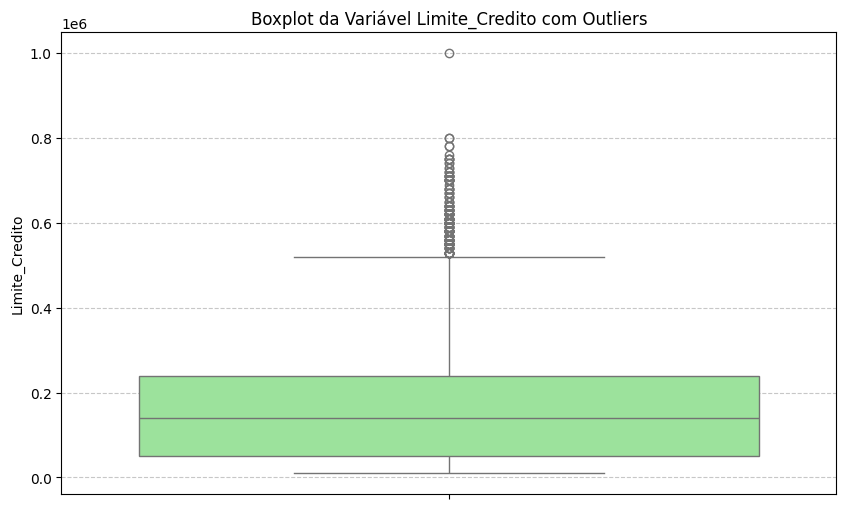

In [154]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Limite_Credito'], color='lightgreen')
plt.title('Boxplot da Variável Limite_Credito com Outliers')
plt.ylabel('Limite_Credito')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Identificação de Outliers usando o Método IQR para `Idade`

In [155]:
# Calcular Q1 (primeiro quartil) e Q3 (terceiro quartil) - Idade

Q1_2 = df['Idade'].quantile(0.25)
Q3_2 = df['Idade'].quantile(0.75)

# Calcular o Intervalo Interquartil (IQR)
IQR_2 = Q3_2 - Q1_2

# Definir os limites para detecção de outliers
lower_bound2 = Q1_2 - 1.5 * IQR_2
upper_bound2 = Q3_2 + 1.5 * IQR_2

# Identificar os outliers
outliers2 = df[(df['Idade'] < lower_bound2) | (df['Idade'] > upper_bound2)]['Idade']

print(f"Q1 (25º percentil): {Q1_2}")
print(f"Q3 (75º percentil): {Q3_2}")
print(f"IQR: {IQR_2}")
print(f"Limite Inferior para Outliers: {lower_bound2}")
print(f"Limite Superior para Outliers: {upper_bound2}")
print(f"Número de Outliers identificados: {len(outliers2)}")

display(outliers2.head()) # Exibe os primeiros outliers, se houver

Q1 (25º percentil): 28.0
Q3 (75º percentil): 41.0
IQR: 13.0
Limite Inferior para Outliers: 8.5
Limite Superior para Outliers: 60.5
Número de Outliers identificados: 272


102     63.0
246     75.0
366     61.0
387     73.0
1029    67.0
Name: Idade, dtype: float64

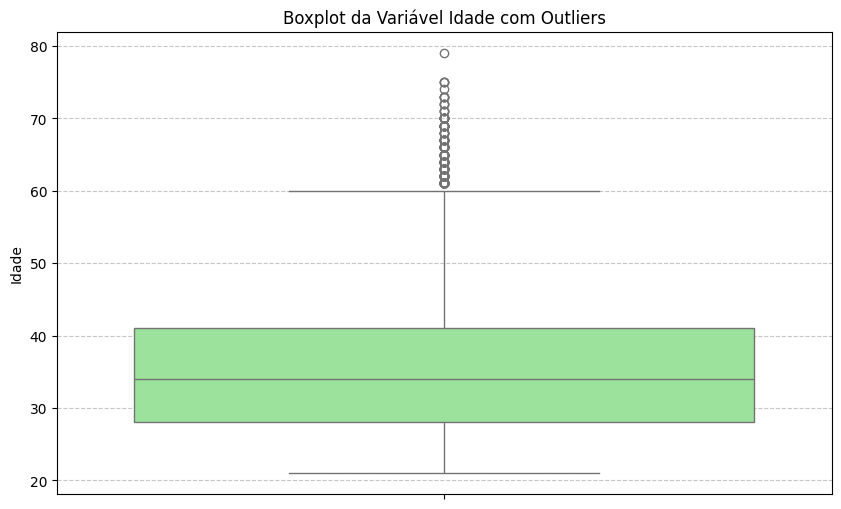

In [156]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Idade'], color='lightgreen')
plt.title('Boxplot da Variável Idade com Outliers')
plt.ylabel('Idade')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### CORRELAÇÕES

In [157]:
# Calcular a matriz de correlação e heatmap

# Calcular a matriz de correlação apenas para colunas numéricas
correlation_matrix = df.select_dtypes(include=np.number).corr()

display(correlation_matrix.head())

,ID_Cliente,Limite_Credito,Escolaridade,Estado_Civil,Idade,Atraso_Pagamento_Setembro,Atraso_Pagamento_Agosto,Atraso_Pagamento_Julho,Atraso_Pagamento_Junho,Atraso_Pagamento_Maio,...,Fatura_Junho,Fatura_Maio,Fatura_Abril,Pagamento_Setembro,Pagamento_Agosto,Pagamento_Julho,Pagamento_Junho,Pagamento_Maio,Pagamento_Abril,Incumprimento_Mes_Seguinte
ID_Cliente,1.000000,0.026179,0.039177,-0.029079,0.018697,-0.030575,-0.011215,-0.018494,-0.002735,-0.022199,...,0.040351,0.016705,0.016730,0.009742,0.008406,0.039151,0.007793,0.000652,0.003000,-0.013952
Limite_Credito,0.026179,1.000000,-0.219161,-0.108139,0.144718,-0.271214,-0.296382,-0.286123,-0.267460,-0.249411,...,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595,-0.153520
Escolaridade,0.039177,-0.219161,1.000000,-0.143464,0.175065,0.105364,0.121566,0.114025,0.108793,0.097520,...,-0.000451,-0.007567,-0.009099,-0.037456,-0.030038,-0.039943,-0.038218,-0.040358,-0.037200,0.028006
Estado_Civil,-0.029079,-0.108139,-0.143464,1.000000,-0.414200,0.019917,0.024199,0.032688,0.033122,0.035629,...,-0.023344,-0.025393,-0.021207,-0.005979,-0.008093,-0.003541,-0.012659,-0.001205,-0.006641,-0.024339
Idade,0.018697,0.144718,0.175065,-0.414200,1.000000,-0.039447,-0.050154,-0.053054,-0.049727,-0.053831,...,0.051374,0.049367,0.047635,0.026147,0.021784,0.029247,0.021378,0.022851,0.019477,0.013895


Análise às Correlações:\
-As variáveis Limite_Credito e as Atraso_Pagamento apresentam uma correlação negativa, e uma correlação positiva com os Pagamentos e Faturas. Isto indica que os clientes com maior crédito apresentam menor risco de atraso no pagamento da mensalidade.\
-As variáveis Faturas e Pagamentos apresentam uma correlação elevada, indicando que o comportamento dos clientes é consistente ao longo do tempo.

### Heatmap da Matriz de Correlação

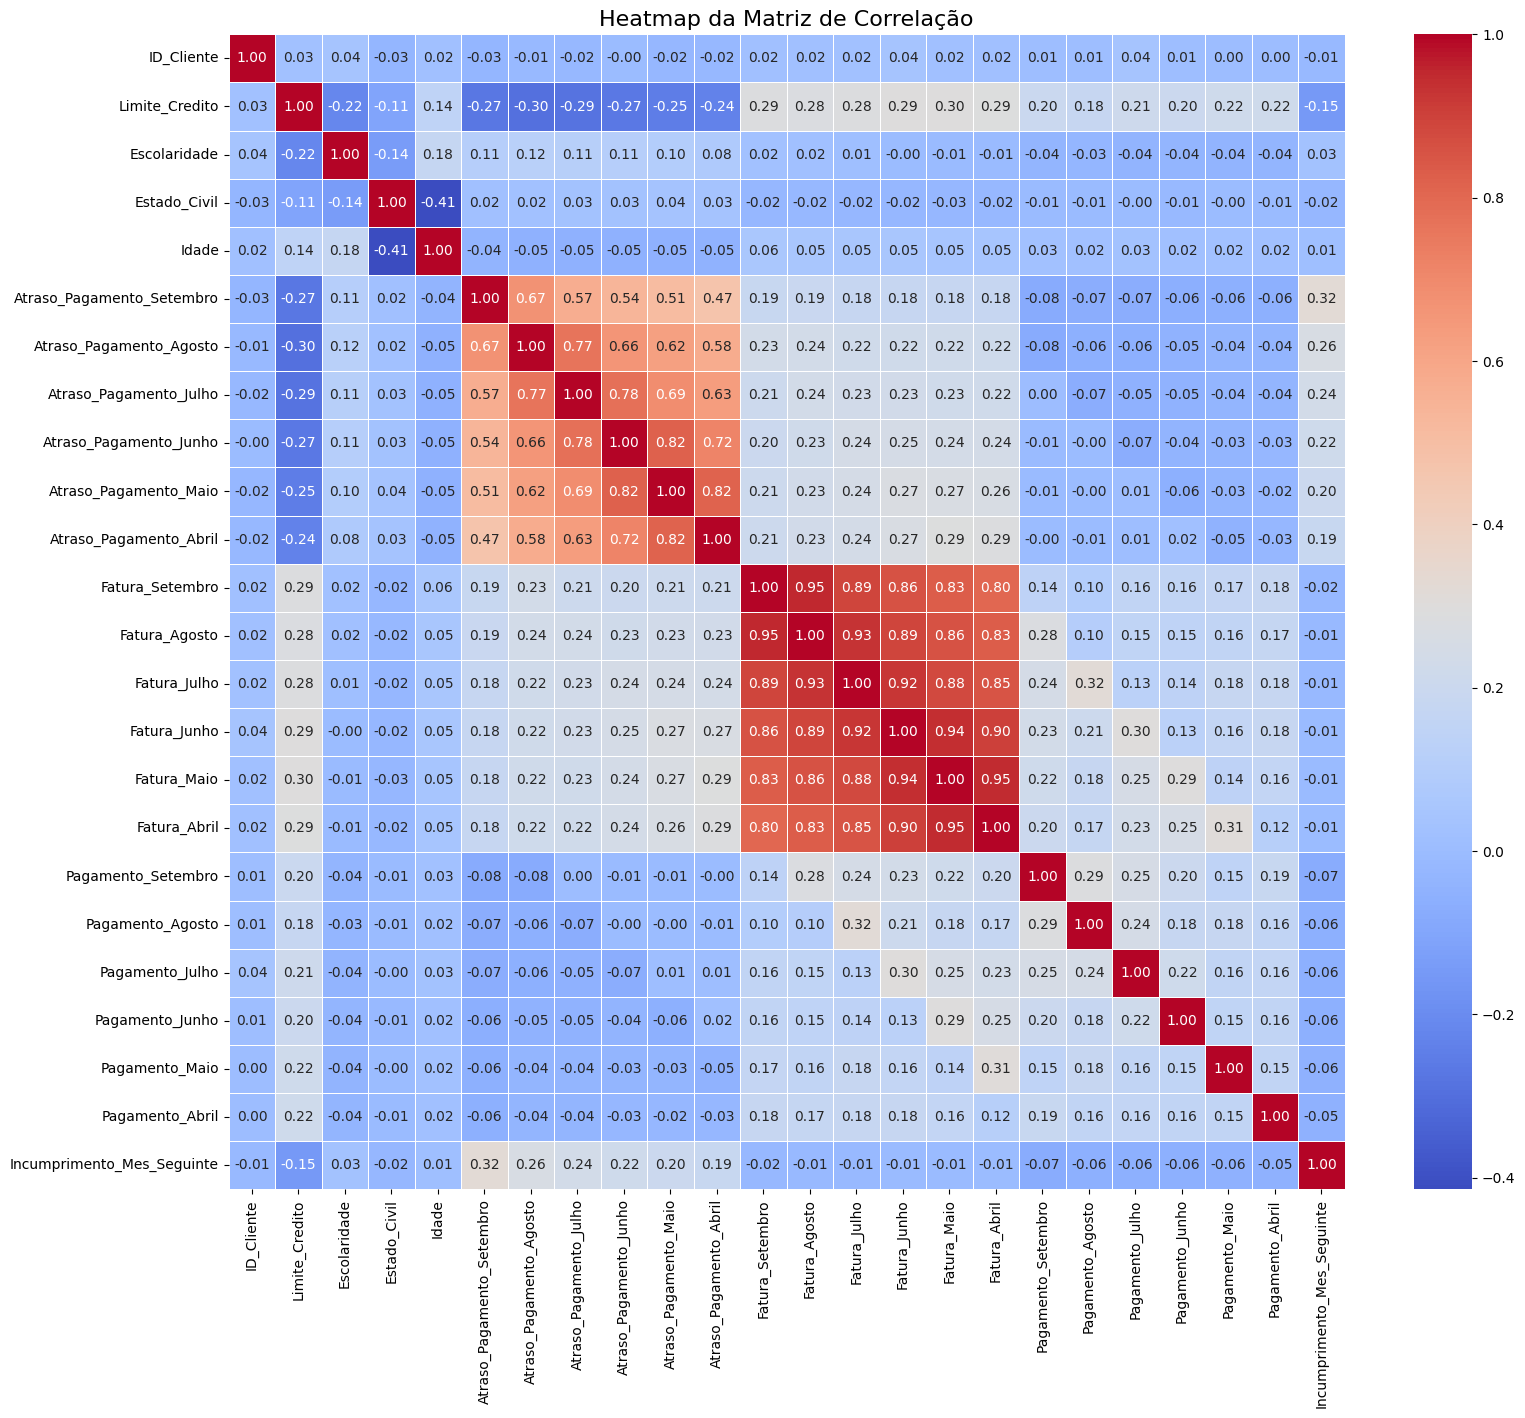

In [121]:
plt.figure(figsize=(18, 15)) # Ajuste o tamanho para melhor visualização
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap da Matriz de Correlação', fontsize=16)
plt.show()

In [122]:
# Método de Correlação - Spearman

correlation_method = 'spearman'

# Calcular a matriz de correlação apenas para colunas numéricas com o método selecionado
correlation_matrix_selected = df.select_dtypes(include=np.number).corr(method=correlation_method)

display(correlation_matrix_selected.head())

,ID_Cliente,Limite_Credito,Escolaridade,Estado_Civil,Idade,Atraso_Pagamento_Setembro,Atraso_Pagamento_Agosto,Atraso_Pagamento_Julho,Atraso_Pagamento_Junho,Atraso_Pagamento_Maio,...,Fatura_Junho,Fatura_Maio,Fatura_Abril,Pagamento_Setembro,Pagamento_Agosto,Pagamento_Julho,Pagamento_Junho,Pagamento_Maio,Pagamento_Abril,Incumprimento_Mes_Seguinte
ID_Cliente,1.000000,0.030636,0.033318,-0.028316,0.024692,-0.025029,-0.004919,-0.009176,-0.004307,-0.015982,...,0.032995,0.015142,0.019961,0.011925,0.050900,0.093546,0.021932,0.012320,0.037875,-0.013952
Limite_Credito,0.030636,1.000000,-0.263575,-0.113535,0.186498,-0.296461,-0.342596,-0.331615,-0.308658,-0.284936,...,0.072894,0.080694,0.088094,0.272367,0.278401,0.284468,0.283411,0.293749,0.317459,-0.169586
Escolaridade,0.033318,-0.263575,1.000000,-0.162415,0.158742,0.132288,0.168715,0.162047,0.151878,0.136501,...,0.069018,0.060286,0.055977,-0.041727,-0.046651,-0.042048,-0.043324,-0.049463,-0.053060,0.044369
Estado_Civil,-0.028316,-0.113535,-0.162415,1.000000,-0.462842,0.023312,0.036950,0.041867,0.044805,0.046881,...,0.005736,0.003680,0.004795,-0.003407,-0.015065,-0.012432,-0.015854,-0.012817,-0.014808,-0.026490
Idade,0.024692,0.186498,0.158742,-0.462842,1.000000,-0.063752,-0.083272,-0.083193,-0.080192,-0.083152,...,-0.003337,-0.000349,0.000212,0.033570,0.044200,0.033358,0.040535,0.038136,0.038988,0.005135


In [123]:
# Método de Correlação - Pearson

correlation_method2 = 'pearson'

# Calcular a matriz de correlação apenas para colunas numéricas com o método selecionado
correlation_matrix_selected2 = df.select_dtypes(include=np.number).corr(method=correlation_method2)

display(correlation_matrix_selected2.head())

,ID_Cliente,Limite_Credito,Escolaridade,Estado_Civil,Idade,Atraso_Pagamento_Setembro,Atraso_Pagamento_Agosto,Atraso_Pagamento_Julho,Atraso_Pagamento_Junho,Atraso_Pagamento_Maio,...,Fatura_Junho,Fatura_Maio,Fatura_Abril,Pagamento_Setembro,Pagamento_Agosto,Pagamento_Julho,Pagamento_Junho,Pagamento_Maio,Pagamento_Abril,Incumprimento_Mes_Seguinte
ID_Cliente,1.000000,0.026179,0.039177,-0.029079,0.018697,-0.030575,-0.011215,-0.018494,-0.002735,-0.022199,...,0.040351,0.016705,0.016730,0.009742,0.008406,0.039151,0.007793,0.000652,0.003000,-0.013952
Limite_Credito,0.026179,1.000000,-0.219161,-0.108139,0.144718,-0.271214,-0.296382,-0.286123,-0.267460,-0.249411,...,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595,-0.153520
Escolaridade,0.039177,-0.219161,1.000000,-0.143464,0.175065,0.105364,0.121566,0.114025,0.108793,0.097520,...,-0.000451,-0.007567,-0.009099,-0.037456,-0.030038,-0.039943,-0.038218,-0.040358,-0.037200,0.028006
Estado_Civil,-0.029079,-0.108139,-0.143464,1.000000,-0.414200,0.019917,0.024199,0.032688,0.033122,0.035629,...,-0.023344,-0.025393,-0.021207,-0.005979,-0.008093,-0.003541,-0.012659,-0.001205,-0.006641,-0.024339
Idade,0.018697,0.144718,0.175065,-0.414200,1.000000,-0.039447,-0.050154,-0.053054,-0.049727,-0.053831,...,0.051374,0.049367,0.047635,0.026147,0.021784,0.029247,0.021378,0.022851,0.019477,0.013895


### Heatmap da Matriz de Correlação (com selecção de método)

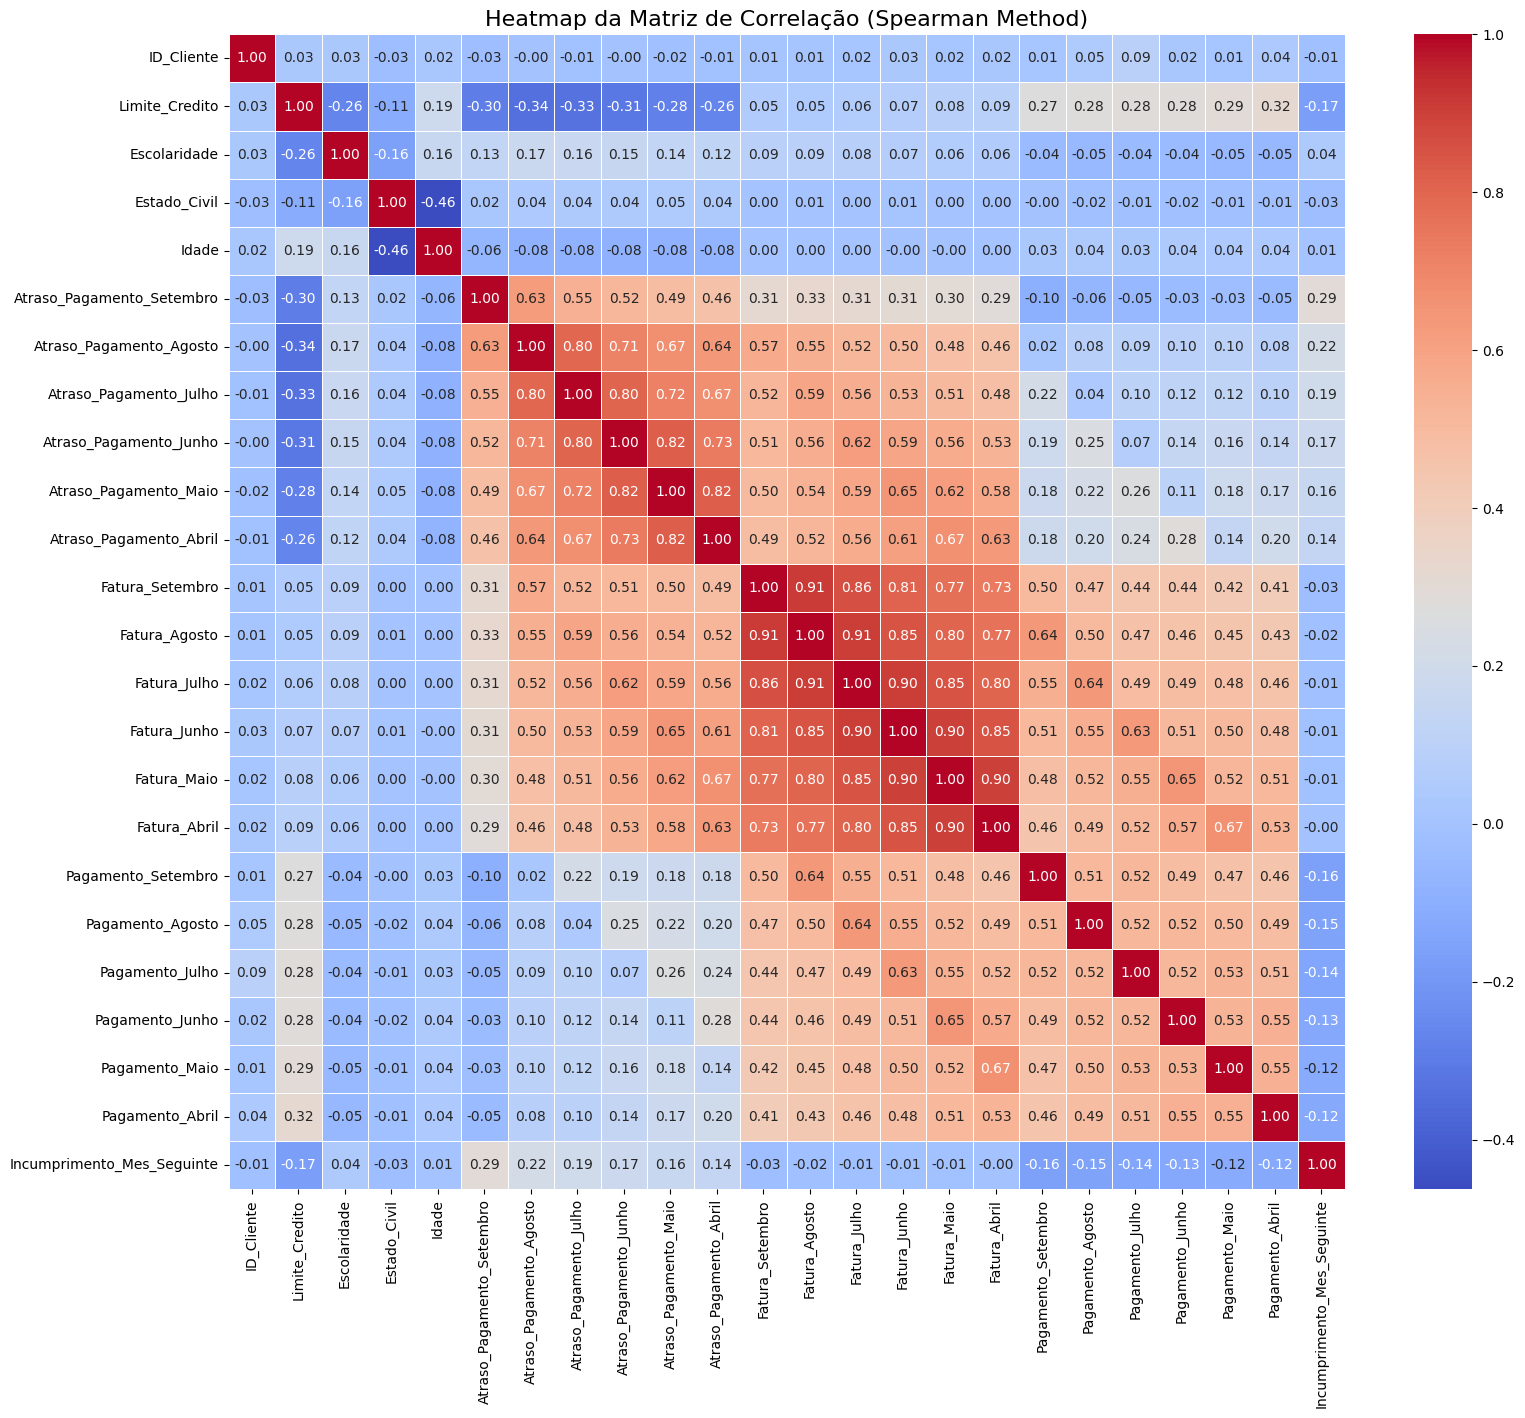

In [124]:
plt.figure(figsize=(18, 15)) # Ajuste o tamanho para melhor visualização
sns.heatmap(correlation_matrix_selected, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title(f'Heatmap da Matriz de Correlação ({correlation_method.capitalize()} Method)', fontsize=16)
plt.show()

CONCLUSÃO DA ANÁLISE ÀS CORRELAÇÕES\
-As variáveis demográficas (Idade, ou Estado Civil) apresentam uma relação muito baixa com as restantes, logo não são relevantes para levar para o modelo ML;\
-No entanto, as variáveis financeiras (faturas, pagamentos), apresentam uma correlação forte entre si. Isto indica que os clientes tendem a manter um padrão nos seus pagamentos;\
-A variável target, Incumprimento_Mes_Seguimento, a variável que pretendemos prever, tem correlações muito baixas com todas as outras variáveis, o que significa que não temos uma razão exacta que explique este incumprimento.

### PARTE II - PRÉ-PROCESSAMENTO DE DADOS

#### SEPARAR A BASE DE DADOS ENTRE TREINO E TESTE PARA O MODELO PREDITIVO

In [125]:
# Separar as features (X) da variável alvo (y)
X = df.drop('Incumprimento_Mes_Seguinte', axis=1)
y = df['Incumprimento_Mes_Seguinte']

# Dividir o dataset em conjuntos de treino e teste
# Usamos stratify=y para garantir que a proporção da variável alvo seja a mesma em treino e teste
# random_state para reprodutibilidade
# Classes desbalanceadas, mais dados de um lado que do outro = stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Tamanho do conjunto de treino (y_train): {y_train.shape}")
print(f"Tamanho do conjunto de teste (y_test): {y_test.shape}")

print(f"Proporção da variável alvo no treino:\n{y_train.value_counts(normalize=True)}")
print(f"Proporção da variável alvo no teste:\n{y_test.value_counts(normalize=True)}")

Tamanho do conjunto de treino (X_train): (21000, 24)
Tamanho do conjunto de teste (X_test): (9000, 24)
Tamanho do conjunto de treino (y_train): (21000,)
Tamanho do conjunto de teste (y_test): (9000,)
Proporção da variável alvo no treino:
Incumprimento_Mes_Seguinte
0    0.77881
1    0.22119
Name: proportion, dtype: float64
Proporção da variável alvo no teste:
Incumprimento_Mes_Seguinte
0    0.778778
1    0.221222
Name: proportion, dtype: float64


#### PREPARAÇÃO DOS DADOS | TRATAMENTO DOS DADOS, VALORES EM FALTA, DUPLICADOS

A Imputação dos dados já foi efectuada, vamos agora analisar valores em falta e duplicados

In [126]:
# Verificar valores ausentes antes da imputação
print("Valores ausentes em X_train antes da imputação:")
print(X_train[['Genero', 'Idade']].isnull().sum())

print("\nValores ausentes em X_test antes da imputação:")
print(X_test[['Genero', 'Idade']].isnull().sum())

# Calcular a moda da coluna 'Genero' no X_train
mode_genero_train = X_train['Genero'].mode()[0]
print(f"\nModa de 'Genero' (X_train): {mode_genero_train}")

# Calcular a mediana da coluna 'Idade' no X_train
median_idade_train = X_train['Idade'].median()
print(f"Mediana de 'Idade' (X_train): {median_idade_train}")

# Preencher valores ausentes na coluna 'Genero' em X_train e X_test
X_train['Genero'] = X_train['Genero'].fillna(mode_genero_train)
X_test['Genero'] = X_test['Genero'].fillna(mode_genero_train)

# Preencher valores ausentes na coluna 'Idade' em X_train e X_test
X_train['Idade'] = X_train['Idade'].fillna(median_idade_train)
X_test['Idade'] = X_test['Idade'].fillna(median_idade_train)

# Verificar valores ausentes após a imputação
print("\nValores ausentes em X_train após a imputação de Genero e Idade:")
print(X_train[['Genero', 'Idade']].isnull().sum())

print("\nValores ausentes em X_test após a imputação de Genero e Idade:")
print(X_test[['Genero', 'Idade']].isnull().sum())

Valores ausentes em X_train antes da imputação:
Genero    2
Idade     4
dtype: int64

Valores ausentes em X_test antes da imputação:
Genero    1
Idade     1
dtype: int64

Moda de 'Genero' (X_train): Feminino
Mediana de 'Idade' (X_train): 34.0

Valores ausentes em X_train após a imputação de Genero e Idade:
Genero    0
Idade     0
dtype: int64

Valores ausentes em X_test após a imputação de Genero e Idade:
Genero    0
Idade     0
dtype: int64


In [127]:
# Transformar a variável categórica Genero em variável numérica
X_train_processed = pd.get_dummies(X_train, columns=['Genero'], drop_first=False)
X_test_processed = pd.get_dummies(X_test, columns=['Genero'], drop_first=False)

# Alinhar colunas; isto é crucial para consjuntos de recursos consistentes entre o treino e teste
common_cols = list(set(X_train_processed.columns) | set(X_test_processed.columns))

X_train_processed = X_train_processed.reindex(columns=common_cols, fill_value=0)
X_test_processed = X_test_processed.reindex(columns=common_cols, fill_value=0)

In [128]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Distribuição original da classe no treino: {Counter(y_train)}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)

print(f"Distribuição da classe no treino após SMOTE: {Counter(y_train_res)}")

Distribuição original da classe no treino: Counter({0: 16355, 1: 4645})
Distribuição da classe no treino após SMOTE: Counter({0: 16355, 1: 16355})


Ao dividirmos a base de dados entre treino e teste, foi verificado que os dados estão desbalanceados Isto acontece porque o próprio dataset também está desbalanceado; 0.778778 ou seja, 77.8% dos clientes cumprem os pagamentos, e 0.221222, 22.2% são incumpridores.\
No entanto, temos de tentar aplicar 50/50 para o modelo ser mais eficaz. Por este motivo, foi usada a função SMOTE, para dividir os dados de forma igual. Mas, este tratamento é efectuado apenas no treino, não no teste, para garantir que o teste permaneça imparcial.

### PARTE III - MODELAGEM

Aplicar a Regressão Logística: previsão do resultado de uma variável com base em uma ou várias variáveis. Permite distinguir a probabilidade de 0 e 1, neste caso se existe ou não incumprimento.

--- Regressão Logística ---
Matriz de Confusão:
[[3651 3358]
 [ 574 1417]]

Recall: 0.7117
Precision: 0.2968
Accuracy: 0.5631
F1-Score: 0.4189


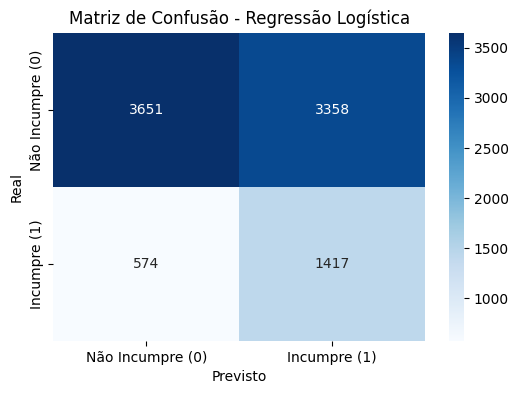

In [129]:
# Importar LogisticRegression - Regressão Logística

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, recall_score, precision_score, accuracy_score, f1_score

# Inicializar e treinar o modelo de Regressão Logística
# random_state para reprodutibilidade
logistic_model = LogisticRegression(random_state=42, solver='liblinear')
logistic_model.fit(X_train_res, y_train_res)

# Fazer previsões no conjunto de teste
y_pred_logistic = logistic_model.predict(X_test_processed)

# Avaliar o desempenho do modelo
conf_matrix_logistic = confusion_matrix(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("--- Regressão Logística ---")
print("Matriz de Confusão:")
print(conf_matrix_logistic)
print(f"\nRecall: {recall_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Accuracy: {accuracy_logistic:.4f}")
print(f"F1-Score: {f1_logistic:.4f}")

# Para uma melhor visualização da matriz de confusão
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_logistic, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Incumpre (0)', 'Incumpre (1)'],
            yticklabels=['Não Incumpre (0)', 'Incumpre (1)'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

O banco tem um custo de FN = 1000€ e um custo de FP = de 150€

In [130]:
# Calcular o Custo Económico - Regressão Logística

FalsosNegativos = 1000 * 574
FalsosPositivos = 150 * 3358
TotalCusto = FalsosNegativos + FalsosPositivos

print (TotalCusto)

1077700


Aplicar a Random Forest: contém várias Árvores de Decisão; cada árvore divide os dados em subconjuntos através de perguntas sequenciais. A Random Forest irá somar e calcular e média de todas estas divisões para obter melhores resultados.

In [131]:
from sklearn.ensemble import RandomForestClassifier

# Instanciar o Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=376, max_depth=19, min_samples_split=7, min_samples_leaf=2 )

# Treinar o modelo
rf_model.fit(X_train_res, y_train_res)

print("Random Forest treinado com sucesso.")

Random Forest treinado com sucesso.


In [132]:
y_pred_rf = rf_model.predict(X_test_processed)

print("Previsões realizadas com sucesso, utilizando o modelo Random Forest.")

Previsões realizadas com sucesso, utilizando o modelo Random Forest.


In [133]:
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("--- Random Forest ---")
print("Matriz de Confusão:")
print(conf_matrix_rf)
print(f"\nRecall: {recall_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

--- Random Forest ---
Matriz de Confusão:
[[6324  685]
 [1069  922]]

Recall: 0.4631
Precision: 0.5737
Accuracy: 0.8051
F1-Score: 0.5125


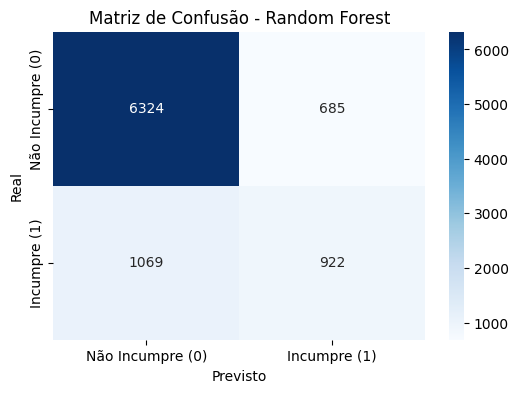

In [134]:
# Matriz de Confusão da Random Forest

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Incumpre (0)', 'Incumpre (1)'],
            yticklabels=['Não Incumpre (0)', 'Incumpre (1)'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Random Forest')
plt.show()

COMPARAÇÃO ENTRE A REGRESSÃO LOGÍSTICA E A RANDOM FOREST\
-A Regressão Logística identificou mais incumpridores, no entanto, erra mais vezes a prever o incumprimento.\
-No entanto, a Random Forest foi o melhor método a identificar que não incumpre, ou seja, os bons pagadores. Devolve menos FP (Falsos Positivos). Mas o custo económico é mais elevado.

In [135]:
# Calcular o Custo Económico - Random Forest

FalsosNegativos2 = 1000 * 1069
FalsosPositivos2 = 150 * 685
TotalCusto2 = FalsosNegativos2 + FalsosPositivos2

print (TotalCusto2)

1171750


In [136]:
# Comparação dos Custos

FN_rf = conf_matrix_rf[1, 0] # Real 1, Previsto 0
FP_rf = conf_matrix_rf[0, 1] # Real 0, Previsto 1

Custo_FN_rf = FN_rf * 1000
Custo_FP_rf = FP_rf * 150

TotalCusto_rf = Custo_FN_rf + Custo_FP_rf

print(f"Custo de Falsos Negativos (Random Forest): {Custo_FN_rf}€")
print(f"Custo de Falsos Positivos (Random Forest): {Custo_FP_rf}€")
print(f"Custo Total (Random Forest): {TotalCusto_rf}€")

print("\n--- Comparação de Custos ---")
print(f"Custo Total (Regressão Logística): {TotalCusto}€")
print(f"Custo Total (Random Forest): {TotalCusto_rf}€")

if TotalCusto_rf < TotalCusto:
    print("O modelo Random Forest tem um custo total menor.")
elif TotalCusto_rf > TotalCusto:
    print("O modelo de Regressão Logística tem um custo total menor.")
else:
    print("Ambos os modelos têm o mesmo custo total.")

Custo de Falsos Negativos (Random Forest): 1069000€
Custo de Falsos Positivos (Random Forest): 102750€
Custo Total (Random Forest): 1171750€

--- Comparação de Custos ---
Custo Total (Regressão Logística): 1077700€
Custo Total (Random Forest): 1171750€
O modelo de Regressão Logística tem um custo total menor.


**O parâmetro Regressão Logística é a melhor opção.**

### PARTE IV - AJUSTAR O THRESHOLD

In [159]:
# Calcular o custo total de cada threshold, 0.4 e 0.6

# Probabilidades previstas para a classe positiva (incumprimento)
y_proba = logistic_model.predict_proba(X_test_processed)[:, 1]

# Thresholds a avaliar
thresholds = [0.4, 0.5, 0.6]

# Custos definidos
COST_FP = 150
COST_FN = 1000

def calcular_custo(cm):
    TN, FP, FN, TP = cm.ravel()
    return FP * COST_FP + FN * COST_FN

resultados = {}

for thr in thresholds:
    y_pred = np.where(y_proba >= thr, 1, 0)
    cm = confusion_matrix(y_test, y_pred)
    custo = calcular_custo(cm)
    resultados[thr] = {"matrix": cm, "custo": custo}

# Mostrar resultados
for thr, info in resultados.items():
    print(f"\n=== Threshold {thr} ===")
    print(info["matrix"])
    print(f"Custo total: {info['custo']} €")

# Encontrar threshold ótimo
threshold_otimo = min(resultados, key=lambda k: resultados[k]["custo"])
print(f"Threshold ótimo = {threshold_otimo} (menor custo económico)")


=== Threshold 0.4 ===
[[1960 5049]
 [ 241 1750]]
Custo total: 998350 €

=== Threshold 0.5 ===
[[3651 3358]
 [ 574 1417]]
Custo total: 1077700 €

=== Threshold 0.6 ===
[[6027  982]
 [1433  558]]
Custo total: 1580300 €
Threshold ótimo = 0.4 (menor custo económico)


ANÁLISE AOS THRESHOLDS\
Treshold 0.4:\
-Aumenta muito o núme\o de verdadeiros positivos, ou seja, identifica mais incumpridores.\
-Reduz drasticamente os FN, o que não é aconselhável acontecer; os clientes que correm o risco de incumprimento não são detectados.\
\
Do ponto de vista económico e como conclusão deste projecto, um FN custa à entidade 1000€, enquanto um FP custa 150€.
Falhar um incumpridor é 6.7 vezes mais caro do que gerar um FP.

### CONCLUSÃO FINAL

O objetivo deste trabalho foi desenvolver um modelo capaz de prever o risco de incumprimento dos clientes do Gomes & Canoso Bank, utilizando técnicas de Machine Learning aplicadas a dados reais de comportamento financeiro. Após a análise exploratória, observou-se que a variável alvo estava desbalanceada, o que implicou utilizar métricas adicionais para garantir uma avaliação mais rigorosa.\
Foram testados diferentes métodos estatísticos e gráficos, incluindo análise de distribuição, testes de hipóteses sobre normalidade, correlações e avaliação de assimetria e curtose.\
Concluiu-se que as variáveis financeiras (faturas mensais, pagamentos, atrasos), são as que apresentam maior capacidade preditiva, enquanto variáveis demográficas (idade, escolaridade, estado civil) têm impacto reduzido. Assim, estas características financeiras foram as que melhor justificaram a sua inclusão no modelo final.\
A Regressão Logística foi o parâmetro escolhido por ser um modelo interpretável e adequado a problemas binários, permitindo também ajustar o threshold para minimizar o custo económico do banco.\
Após testar diferentes thresholds, concluiu-se que o valor 0.4 é o mais eficiente, reduzindo de forma significativa os FP, que representam o maior risco financeiro.\
O modelo final revela-se uma solução simples, explicável e eficaz para apoiar decisões de crédito.